# Causal Inference ~ Group 10

## Part (a)

We simulate samples of coin tosses where the random variable \( X \) has pmf:

\[
P(X = x) =
\begin{cases}
0.5 & \text{if } x = 1 \\
0.5 & \text{if } x = 0
\end{cases}
\]

Thus, $X \sim \text{Bernoulli}(0.5)$ and $\mathbb{E}[X] = 0.5$.

We generate 1,000 samples of size \( n = 5 \), compute the sample mean for each, and calculate the proportion of sample means that lie within:

\[
[0.4, 0.6]
\]

(i.e., within 0.1 of the true expectation 0.5).


In [1]:
import numpy as np

np.random.seed(0)

n = 5
num_samples = 1000

means = []

for _ in range(num_samples):
    sample = np.random.binomial(1, 0.5, n)
    means.append(np.mean(sample))

means = np.array(means)

prop = np.mean((means >= 0.4) & (means <= 0.6))

print(prop)

0.633


## Part (b)

We repeat the simulation from part (a) with sample sizes:

- \( n = 15 \)
- \( n = 100 \)

We compute the proportion of sample means within:

\[
[0.4, 0.6]
\]


In [2]:
for n in [15, 100]:
    means = []
    for _ in range(1000):
        sample = np.random.binomial(1, 0.5, n)
        means.append(np.mean(sample))
    means = np.array(means)
    prop = np.mean((means >= 0.4) & (means <= 0.6))
    print(f"n = {n}, proportion = {prop}")

n = 15, proportion = 0.705
n = 100, proportion = 0.96


## Part (c)

As the sample size increases, the proportion of sample means within the interval 
\([0.4, 0.6]\) increases.

This result follows from the **Law of Large Numbers (LLN)** and the **Central Limit Theorem (CLT)**.

The Law of Large Numbers states that as $n \to \infty$, the sample mean $\bar{X}_n$ converges to the true expectation $\mathbb{E}[X] = 0.5$.

Additionally, the Central Limit Theorem states:

$$
\sqrt{n}\,(\bar{X}_n - 0.5) \xrightarrow{d} \mathcal{N}(0, \sigma^2)
$$

Since the variance of a Bernoulli(0.5) variable is

$$
\sigma^2 = 0.5(1 - 0.5) = 0.25
$$

the distribution of the sample mean becomes increasingly concentrated around 0.5 as $n$ increases.

Thus, larger sample sizes produce smaller variance in the sample mean, increasing the probability that it lies close to the true mean.


## Part (d)

We now plot histograms of:

$$
\sqrt{n}\,(\bar{X}_n - 0.5)
$$

for:

- $n = 5$
- $n = 15$
- $n = 100$

By the Central Limit Theorem:

$$
\sqrt{n}\,(\bar{X}_n - 0.5) \xrightarrow{d} \mathcal{N}(0, 0.25)
$$

So we expect the histograms to increasingly resemble a Normal distribution 
centered at 0 with variance 0.25 as \( n \) increases.


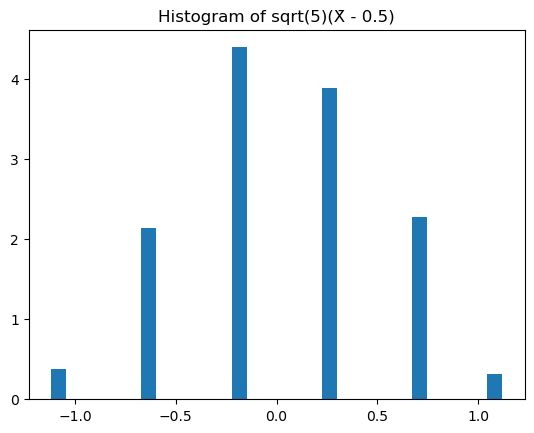

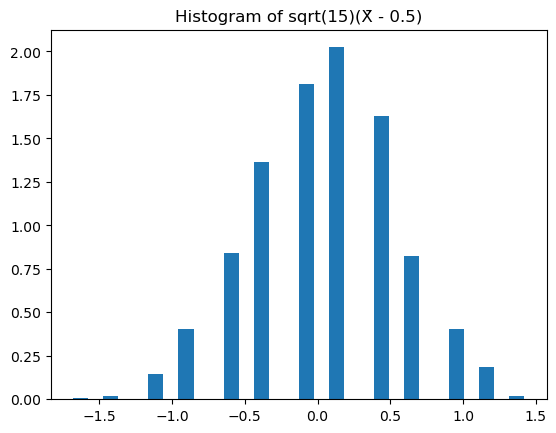

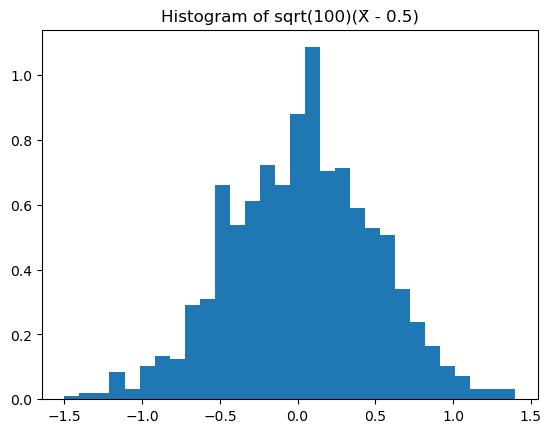

In [3]:
import matplotlib.pyplot as plt

sample_sizes = [5, 15, 100]

for n in sample_sizes:
    values = []
    for _ in range(1000):
        sample = np.random.binomial(1, 0.5, n)
        mean = np.mean(sample)
        values.append(np.sqrt(n) * (mean - 0.5))
    
    plt.figure()
    plt.hist(values, bins=30, density=True)
    plt.title(f"Histogram of sqrt({n})(X̄ - 0.5)")
    plt.show()


## Interpretation

As the sample size increases from $n = 5$ to $n = 100$, the distribution of $\sqrt{n}(\bar{X} - 0.5)$ becomes smoother and more bell-shaped. For $n = 5$, the histogram is discrete and irregular because the sample mean can only take a limited number of possible values, but by $n = 100$ it closely resembles a continuous normal distribution centered around $0$. This pattern is consistent with the Central Limit Theorem, which states that $\sqrt{n}(\bar{X} - \mu)$ converges in distribution to a normal distribution as the sample size increases.
